<a href="https://colab.research.google.com/github/fadeeva/nakedML/blob/master/MLnotes/002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")

print("Path to dataset files:", path)

100%|██████████| 119k/119k [00:00<00:00, 46.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kumarajarshi/life-expectancy-who/versions/1


In [3]:
rng = np.random.default_rng()

In [4]:
df = pd.read_csv(f'{path}/Life Expectancy Data.csv')
df.drop('Status', inplace=True, axis=1)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,Country,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# /02
*part 2*

## Data Normalization

### Min-max

All values in the interval [0, 1]

$$
p'_i = \frac{p_i - min\{p_i\}}{max\{p_i\} - min\{p_i\}}
$$

Skew:
Original: -0.63
Normalized: -0.63


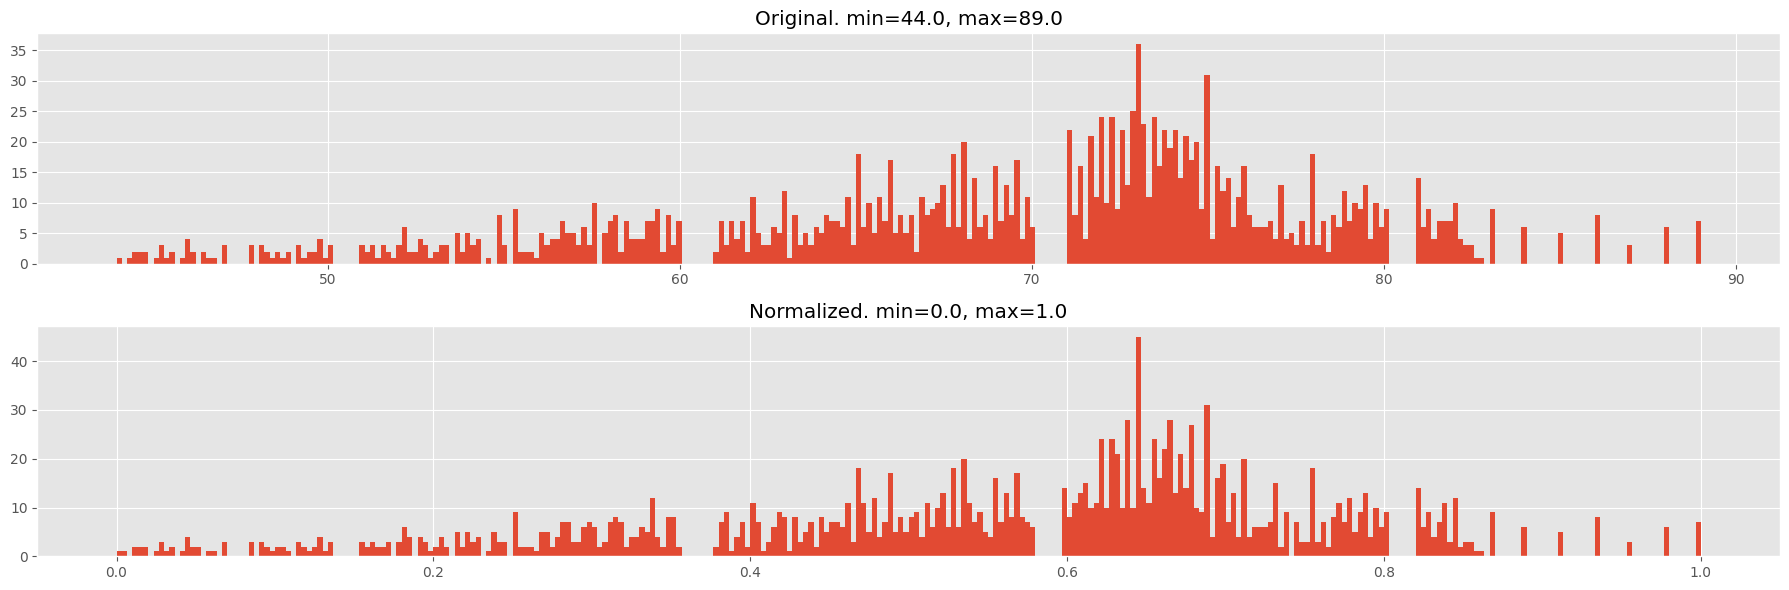

In [31]:
life_exp_norm = (df['Life expectancy '] - df['Life expectancy '].min()) / \
(df['Life expectancy '].max() - df['Life expectancy '].min())

print(f'Skew:\nOriginal: {np.round(stats.skew(df['Life expectancy ']), 2)}')
print(f'Normalized: {np.round(stats.skew(life_exp_norm), 2)}')

fig, axs = plt.subplots(2, 1, figsize=(18, 6))

axs[0].hist(df['Life expectancy '], bins=300)
axs[0].set_title(f'Original. min={df['Life expectancy '].min()}, max={df['Life expectancy '].max()}')

axs[1].hist(life_exp_norm, bins=300)
axs[1].set_title(f'Normalized. min={life_exp_norm.min()}, max={life_exp_norm.max()}')

plt.tight_layout()

### Z-score
The mean will be 0, standard deviation 1
$$
p_i = \frac{p_i - \mu}{\sigma}
$$

Skew:
Original: -2.36
Normalized: -2.36


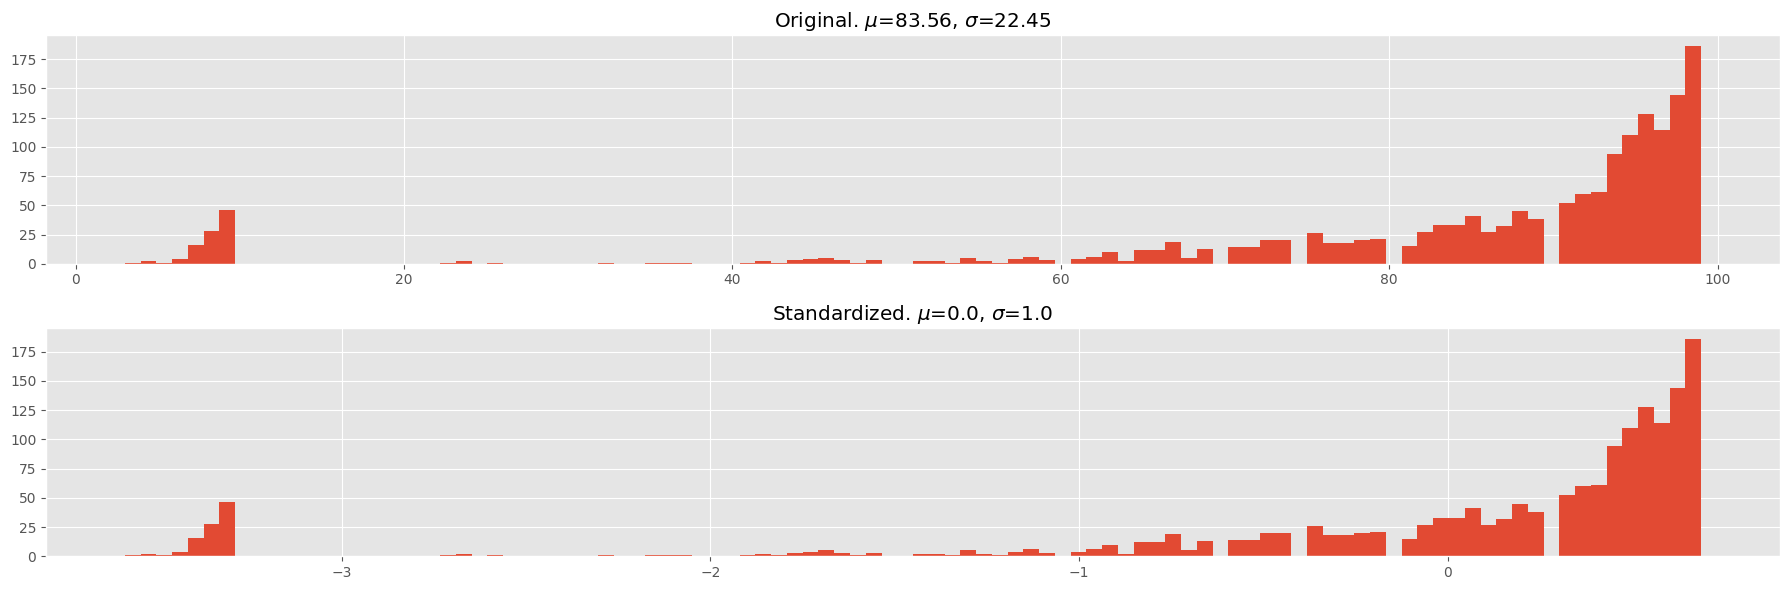

In [40]:
polio_z = (df['Polio'] - df['Polio'].mean()) / df['Polio'].std()

print(f'Skew:\nOriginal: {np.round(stats.skew(df['Polio']), 2)}')
print(f'Normalized: {np.round(stats.skew(polio_z), 2)}')

fig, axs = plt.subplots(2, 1, figsize=(18, 6))

axs[0].hist(df['Polio'], bins=100)
axs[0].set_title(fr'Original. $\mu$={np.round(df['Polio'].mean(), 2)}, $\sigma$={np.round(df['Polio'].std(), 2)}')

axs[1].hist(polio_z, bins=100)
axs[1].set_title(fr'Standardized. $\mu$={np.round(polio_z.mean(), 2)}, $\sigma$={np.round(polio_z.std(), 2)}')

plt.tight_layout()

### Logarithm

Used for highly skewed data

Skew:
Original: 4.51
Normalized: -0.23


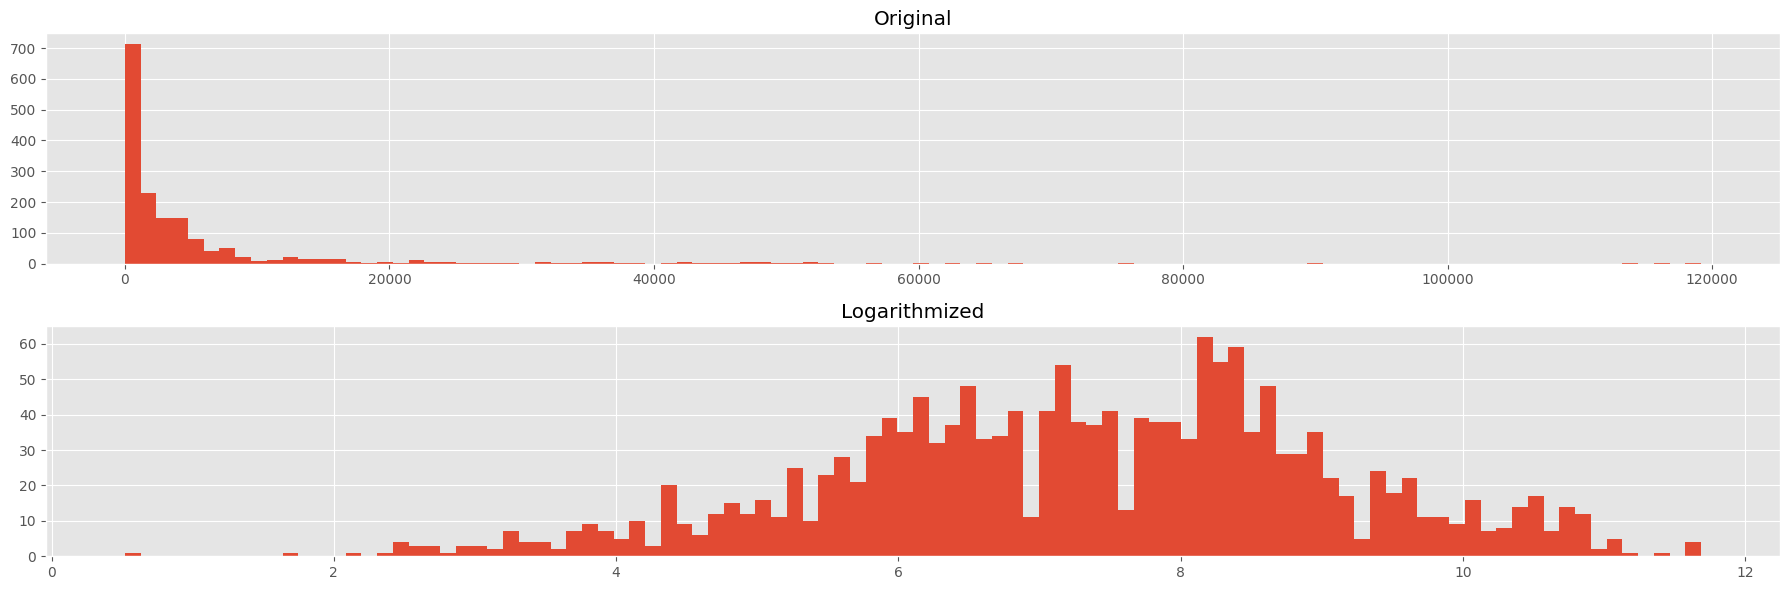

In [41]:
gdp_log = np.log(df['GDP'])

print(f'Skew:\nOriginal: {np.round(stats.skew(df['GDP']), 2)}')
print(f'Normalized: {np.round(stats.skew(gdp_log), 2)}')

fig, axs = plt.subplots(2, 1, figsize=(18, 6))

axs[0].hist(df['GDP'], bins=100)
axs[0].set_title('Original')

axs[1].hist(gdp_log, bins=100)
axs[1].set_title('Logarithmized')

plt.tight_layout()